<a href="https://colab.research.google.com/github/lookmeebbear/Geoimg_SVCU/blob/main/GeoAI_LandcoverClassification_LookmeeSVCU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Automatic Landcover Classification by Python Programming**

2108627 Geoimage Processing


Thepchai Srinoi, MEng

Department of Survey Engineering

Faculty of Engineering Chulalongkorn University

-------------------------------------------------------------

activate google earth engine

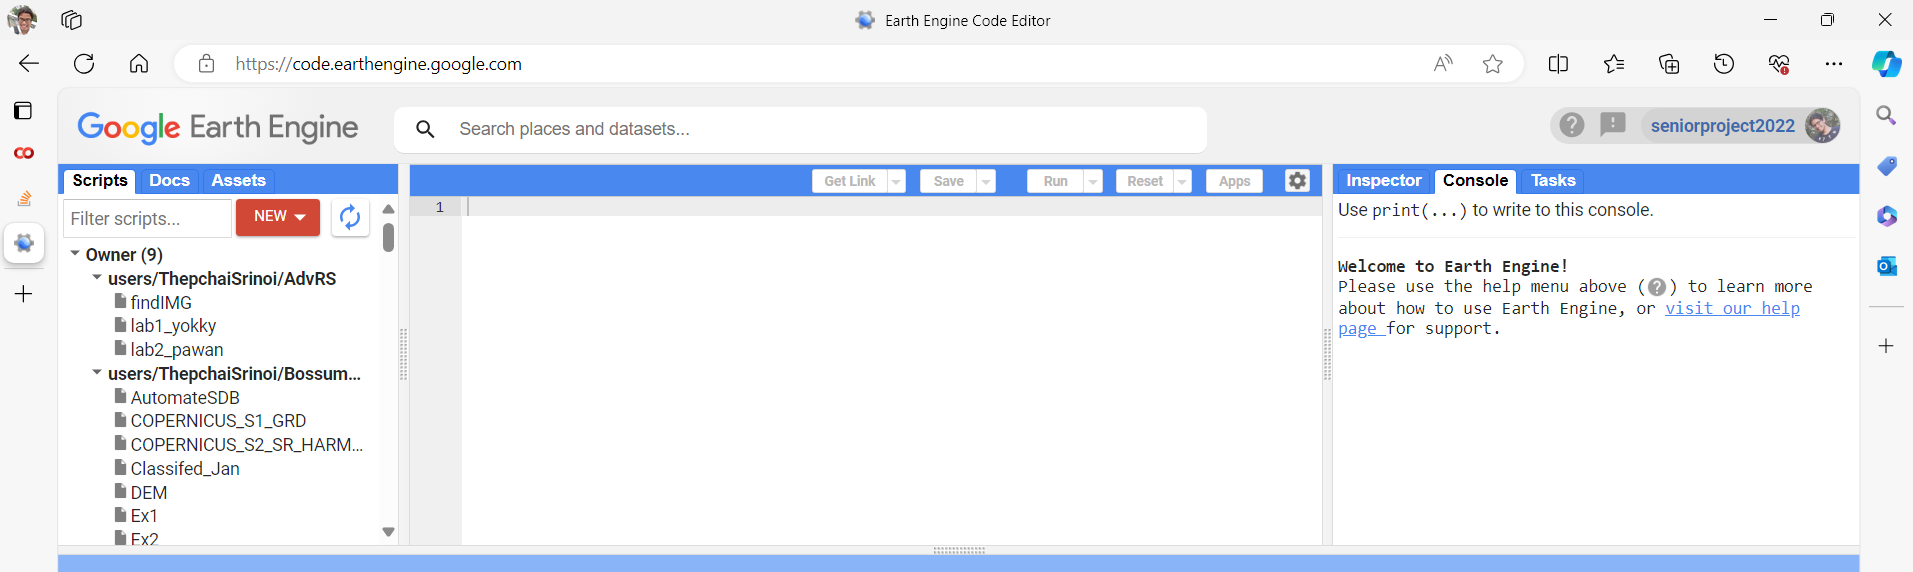

In [ ]:
import ee
# Authenticate to the Earth Engine servers
ee.Authenticate()
# Initialize the API
ee.Initialize(project='seniorproject2022')

เอาไว้แสดงแผนที่ออนไลน์ผ่านไพธอน

In [ ]:
import folium

# Map Visualization : Google Earth Engine
def add_ee_layer(self, ee_image_object, vis_params, name):
  map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)
  folium.raster_layers.TileLayer(
      tiles=map_id_dict['tile_fetcher'].url_format,
      attr='Map Data &copy; <a href="https://earthengine.google.com/">Google Earth Engine</a>',
      name=name,
      overlay=True,
      control=True
  ).add_to(self)

ค้นภาพดาวเทียมจาก google earth engine

In [ ]:
# Retrieve satellite image
lat_min, lat_max, lon_min, lon_max = (13.920, 14.000, 100.4, 100.55)
AOI = ee.Geometry.Polygon(
        [[[lon_min, lat_max],
           [lon_min, lat_min],
           [lon_max, lat_min],
           [lon_max, lat_max]]])

fromdate = '2022-01-01'
todate = '2022-02-01'

myimage = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED').filterDate(fromdate,todate).\
            filterMetadata('CLOUDY_PIXEL_PERCENTAGE','less_than',1).\
            filterBounds(AOI).mosaic().divide(10000).clip(AOI).\
            select(['B1', 'B2', 'B3', 'B4', 'B5',
                    'B6', 'B7', 'B8', 'B8A', 'B9', 'B11', 'B12'])

#True Composite Visualization
folium.Map.add_ee_layer = add_ee_layer
c = (AOI.centroid().getInfo())['coordinates']
map_matched = folium.Map(location=[c[1], c[0]], zoom_start=13.8)
map_matched.add_ee_layer(myimage,{'min':0, 'max':0.3, 'bands':['B6', 'B5', 'B4']},'myimage_falsecolor')
map_matched.add_ee_layer(myimage,{'min':0, 'max':0.3, 'bands':['B4', 'B3', 'B2']},'myimage_truecolor')
display(map_matched.add_child(folium.LayerControl()))

บันทึกภาพดาวเทียมเข้า Google Drive

In [ ]:
task = ee.batch.Export.image.toDrive(**{
    'image': myimage,
    'description': 'sentinel2_nonthaburi',
    'folder':'GeoAI_SVCU',
    'scale': 10,
    'region': AOI.getInfo()['coordinates']
})
task.start()

import time
while task.active():
  print('Polling for task (id: {}).'.format(task.id))
  time.sleep(5)

Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).
Polling for task (id: SIRERVSKA6YDF2ZTOM4WDY67).


mount google drive please ....

In [ ]:
PATH = '/content/drive/MyDrive/GeoAI_SVCU/sentinel2_nonthaburi.tif'

นำเข้าภาพดาวเทียม แล้วเล่นแม่งเลย

In [ ]:
import rasterio as rio

In [ ]:
myimg = rio.open( PATH )
type(myimg)

rasterio.io.DatasetReader

In [ ]:
img = myimg.read()
type(img)

numpy.ndarray

In [ ]:
myimg.count, myimg.width, myimg.height

(12, 1671, 892)

แสดงข้อมูลภาพในแบนด์แรก

In [ ]:
myimg.read(1)

array([[0.0475, 0.0475, 0.0475, ..., 0.0168, 0.0168, 0.0168],
       [0.0475, 0.0475, 0.0475, ..., 0.0168, 0.0168, 0.0168],
       [0.0475, 0.0475, 0.0475, ..., 0.0168, 0.0168, 0.0168],
       ...,
       [0.0658, 0.0658, 0.0658, ..., 0.1083, 0.1083, 0.1083],
       [0.0658, 0.0658, 0.0658, ..., 0.1083, 0.1083, 0.1083],
       [0.0658, 0.0658, 0.0658, ..., 0.1083, 0.1083, 0.1083]],
      dtype=float32)

In [ ]:
img[0]

array([[0.0475, 0.0475, 0.0475, ..., 0.0168, 0.0168, 0.0168],
       [0.0475, 0.0475, 0.0475, ..., 0.0168, 0.0168, 0.0168],
       [0.0475, 0.0475, 0.0475, ..., 0.0168, 0.0168, 0.0168],
       ...,
       [0.0658, 0.0658, 0.0658, ..., 0.1083, 0.1083, 0.1083],
       [0.0658, 0.0658, 0.0658, ..., 0.1083, 0.1083, 0.1083],
       [0.0658, 0.0658, 0.0658, ..., 0.1083, 0.1083, 0.1083]],
      dtype=float32)

boundary box of image

In [ ]:
myimg.bounds

BoundingBox(left=100.39993823503308, bottom=13.919934316602458, right=100.55004671900944, top=14.000064039945919)

Coordinate Conversion

In [ ]:
myimg.transform

Affine(8.983152841195215e-05, 0.0, 100.39993823503308,
       0.0, -8.983152841195215e-05, 14.000064039945919)

row, col to lon lat (World X Y)

In [ ]:
# [lon lat] = A*[row, col]
myimg.transform*(100,120)

(100.40892138787427, 13.989284256536484)

lon lat to col row

In [ ]:
myimg.index(100.40892138787427, 13.989284256536484)

(120, 100)

sample raster value --> spectral reflectance

0.0201
[0.0201 0.0416 0.065  0.0517 0.0818 0.1371 0.1507 0.1224 0.1449 0.1681
 0.077  0.0463]


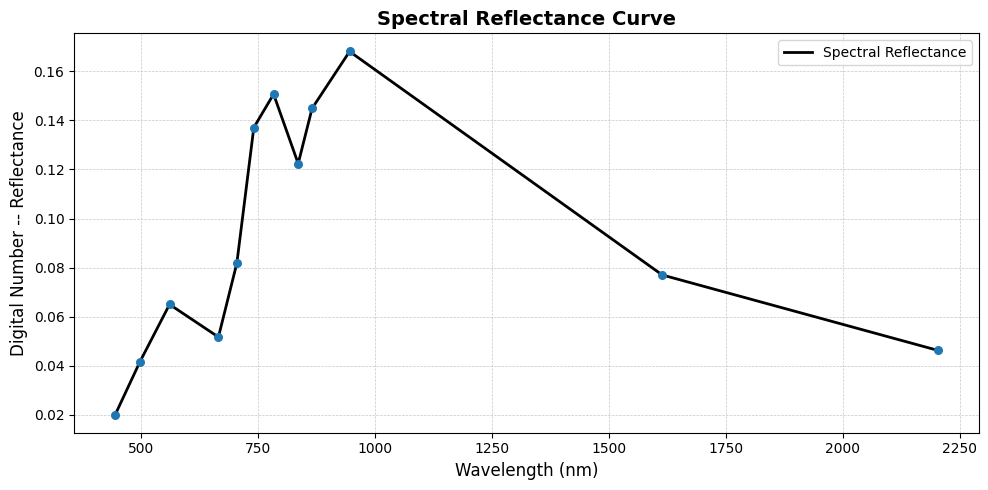

In [ ]:
import matplotlib.pyplot as plt

testb = myimg.read(1)
x = 100.408921
y = 13.98928

print( testb[ myimg.index(x,y) ] )

for val in myimg.sample( [(x,y)] ):
  print(val)

# Wavelength
wv = [443.9, 496.6, 560, 664.5, 703.9, 740.2, 782.5, 835.1, 864.8, 945, 1613.7, 2202.4]



# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot spectral reflectance
ax.plot(wv, val, color='black', linewidth=2, label='Spectral Reflectance')
ax.scatter(wv, val, s=30, zorder=3)  # points on top
# Labels (with units)
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Digital Number -- Reflectance', fontsize=12)

# Title
ax.set_title('Spectral Reflectance Curve', fontsize=14, fontweight='bold')

# Grid (academic style)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Ticks formatting
ax.tick_params(axis='both', which='major', labelsize=10)

# Optional: set limits if needed
# ax.set_xlim(min(wv), max(wv))
# ax.set_ylim(0, 1)

# Legend
ax.legend(fontsize=10)

# Tight layout for clean spacing
plt.tight_layout()

# Show plot
plt.show()

เปิดภาพดาวเทียมกันเถอะ

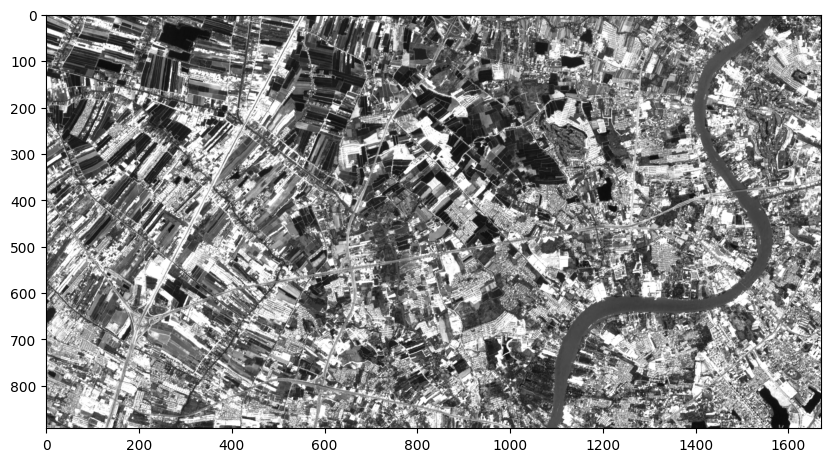

In [ ]:
fig,ax = plt.subplots(1,1, figsize=(10,20))
plt.imshow(img[3], cmap='Greys_r', vmin=0, vmax=0.2)

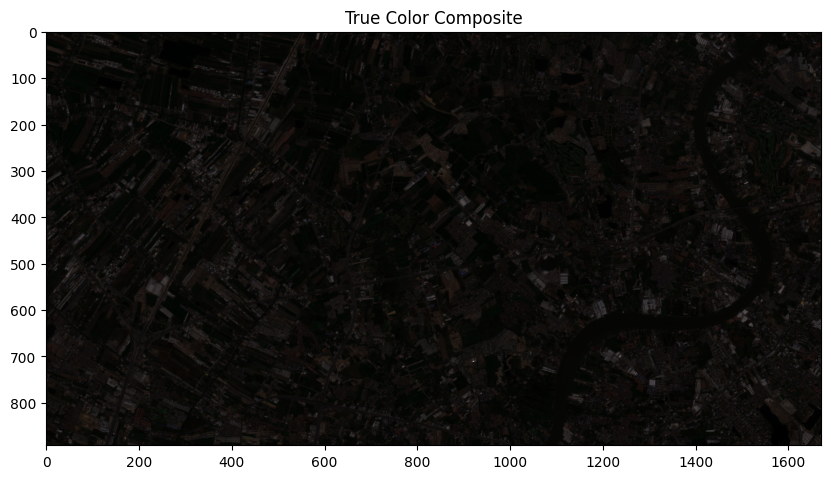

<Axes: title={'center': 'True Color Composite'}>

In [ ]:
from rasterio.plot import show, adjust_band
RGB = img[[3,2,1],:,:]
#RGB_norm = adjust_band(RGB)

fig,ax = plt.subplots(1,1, figsize=(10,20))
ax.set_title('True Color Composite')
show( RGB )

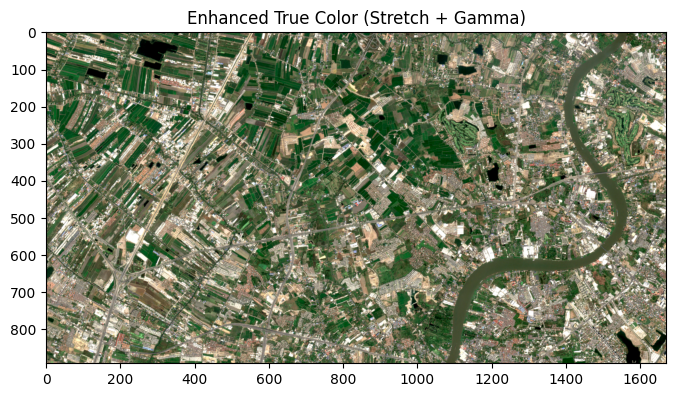

In [ ]:
# Stretch first
import numpy as np
RGB = img[[3,2,1],:,:]
p2, p98 = np.percentile(RGB, (2, 98))
RGB_stretch = np.clip((RGB - p2) / (p98 - p2), 0, 1)

# Then gamma
RGB_final = np.power(RGB_stretch, 0.6)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_title('Enhanced True Color (Stretch + Gamma)')
show(RGB_final, ax=ax)
plt.show()

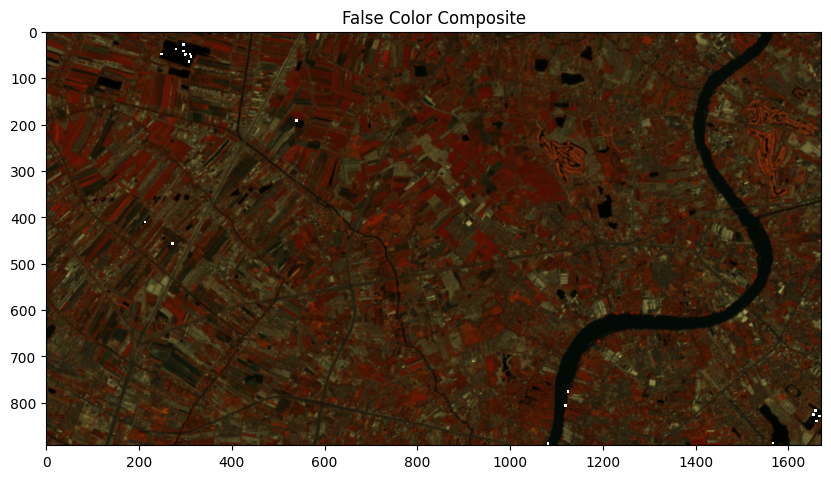

<Axes: title={'center': 'False Color Composite'}>

In [ ]:
from rasterio.plot import show, adjust_band
RGB = img[[5,4,3],:,:]
#RGB_norm = adjust_band(RGB)

fig,ax = plt.subplots(1,1, figsize=(10,25))
ax.set_title('False Color Composite')
show( RGB , vmin=0, vmax=0.2 )

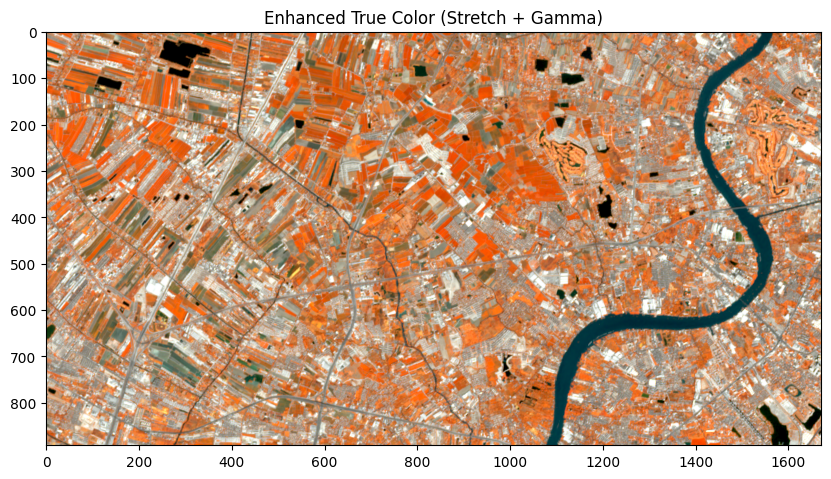

In [ ]:
# Stretch first
import numpy as np
RGB = np.nan_to_num(RGB, nan=0)
p2, p98 = np.percentile(RGB, (2, 98))
RGB_stretch = np.clip((RGB - p2) / (p98 - p2), 0, 1)

# Then gamma
RGB_final = np.power(RGB_stretch, 0.6)

fig, ax = plt.subplots(figsize=(10, 25))
ax.set_title('Enhanced True Color (Stretch + Gamma)')
show(RGB_final, ax=ax)
plt.show()

Spatial Subset

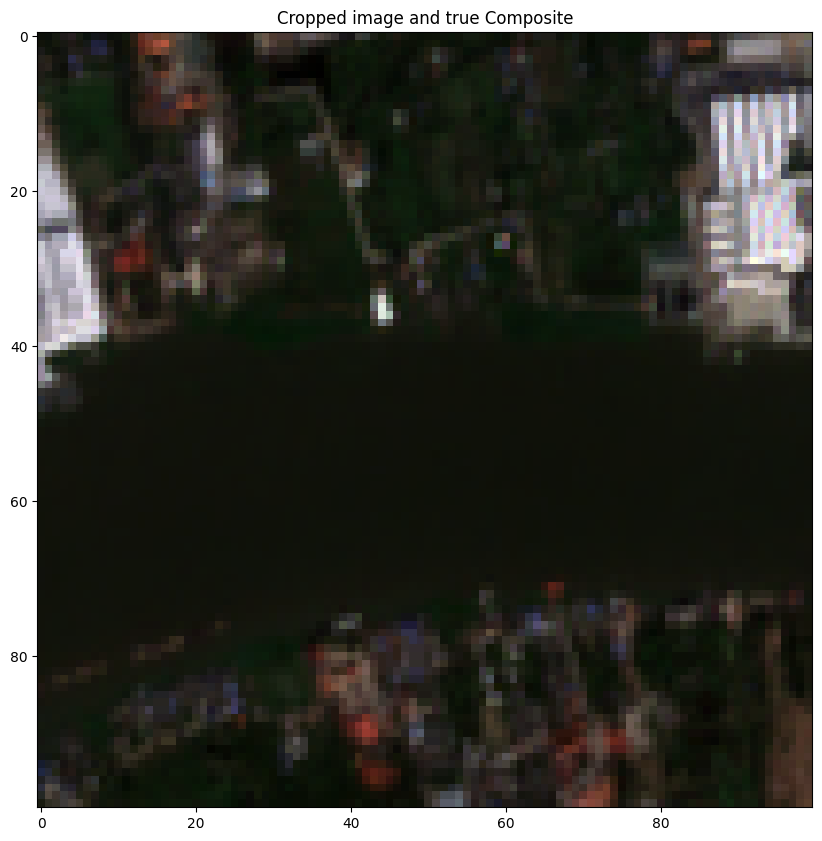

<Axes: title={'center': 'Cropped image and true Composite'}>

In [ ]:
from rasterio.windows import Window
window = Window(1200, 570, 100, 100)
Crop_img = myimg.read( window=window )
RGB = Crop_img[[3,2,1],:,:]
RGB_norm = adjust_band(RGB)

fig,ax = plt.subplots(1,1, figsize=(10,25))
ax.set_title('Cropped image and true Composite')
show( RGB_norm , vmin=0, vmax=0.3 )

import sample point

0 - building and artificial place

1 - agriculture

2 - water

In [ ]:
import pandas as pd
df = pd.read_csv('https://raw.githubusercontent.com/lookmeebbear/OpenRS_LDDTNI/main/landcover_samplepoint.csv')
df

,X,Y,class
0,100.533771,13.924564,0
1,100.516601,13.935989,0
2,100.511406,13.930158,0
3,100.512136,13.922949,0
4,100.542498,13.934334,0
...,...,...,...
175,100.439966,13.932960,2
176,100.435115,13.940927,2
177,100.415455,13.947197,2
178,100.429210,13.947346,2


In [ ]:
import geopandas as gpd
from shapely.geometry import Point

# df has columns: lat, lon, class
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.X, df.Y),
    crs="EPSG:4326"   # WGS84 (lat/lon)
)

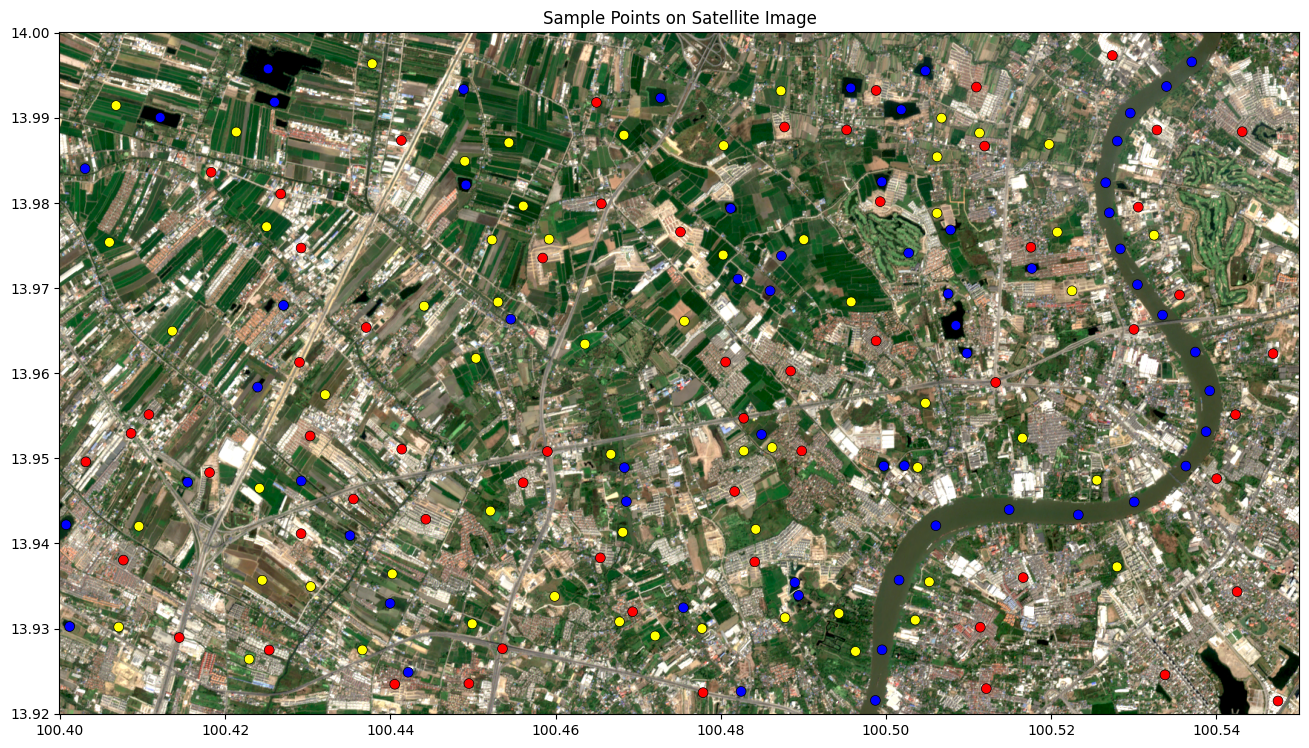

In [ ]:
import matplotlib.pyplot as plt
from rasterio.plot import show
from matplotlib.colors import ListedColormap

fig, ax = plt.subplots(figsize=(16, 16))

# Show satellite image
RGB = myimg.read([4,3,2])
p2, p98 = np.percentile(RGB, (2, 98))
RGB_stretch = np.clip((RGB - p2) / (p98 - p2), 0, 1)

# Then gamma
RGB_final = np.power(RGB_stretch, 0.6)
show(RGB_final , transform=myimg.transform, ax=ax)

cmap = ListedColormap(['red', 'yellow', 'blue'])

gdf.plot(
    ax=ax,
    column='class',
    cmap=cmap,
    markersize=50,
    edgecolor='black',
    linewidth=0.5,
)

ax.set_title('Sample Points on Satellite Image')
plt.show()

In [ ]:
df['value'] = [ x for x in myimg.sample( [(x,y) for x,y in zip(df.X, df.Y)] ) ]
df

,X,Y,class,value
0,100.533771,13.924564,0,"[0.0732, 0.0964, 0.1042, 0.1138, 0.1337, 0.156..."
1,100.516601,13.935989,0,"[0.0864, 0.1126, 0.1388, 0.1416, 0.1728, 0.190..."
2,100.511406,13.930158,0,"[0.0656, 0.1138, 0.1264, 0.1282, 0.1298, 0.151..."
3,100.512136,13.922949,0,"[0.0583, 0.0692, 0.0832, 0.116, 0.1399, 0.1606..."
4,100.542498,13.934334,0,"[0.0656, 0.1086, 0.0971, 0.0872, 0.1165, 0.128..."
...,...,...,...,...
175,100.439966,13.932960,2,"[0.0203, 0.0357, 0.0559, 0.0428, 0.0617, 0.018..."
176,100.435115,13.940927,2,"[0.0218, 0.0208, 0.0281, 0.0213, 0.0382, 0.039..."
177,100.415455,13.947197,2,"[0.0165, 0.0194, 0.02, 0.0095, 0.0127, 0.0153,..."
178,100.429210,13.947346,2,"[0.0172, 0.016, 0.0206, 0.0142, 0.025, 0.0115,..."


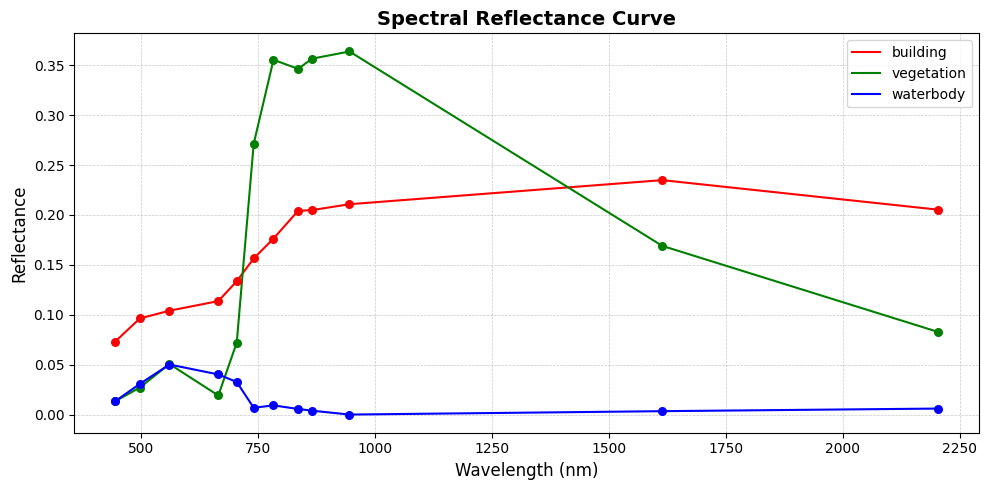

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
# Labels
ax.set_xlabel('Wavelength (nm)', fontsize=12)
ax.set_ylabel('Reflectance', fontsize=12)

# Title
ax.set_title('Spectral Reflectance Curve', fontsize=14, fontweight='bold')

# Grid
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)

# Tick formatting
ax.tick_params(axis='both', labelsize=10)

mybuilding = ( df.iloc[0] ).value
myvegetation = ( df.iloc[60] ).value
mywater = ( df.iloc[124] ).value

ax.plot( wv, mybuilding , color='red', label = 'building' )
ax.scatter(wv, mybuilding, s=30, zorder=3, color='red')  # points on top

ax.plot( wv, myvegetation , color='green', label = 'vegetation')
ax.scatter(wv, myvegetation, s=30, zorder=3, color='green')  # points on top

ax.plot( wv, mywater , color='blue' , label = 'waterbody' )
ax.scatter(wv, mywater, s=30, zorder=3, color='blue')  # points on top

# Legend
ax.legend()

# Clean layout
plt.tight_layout()

# Show
plt.show()

In [ ]:
mycol = [i for i in range(myimg.count) ]
df[ mycol ] = [x for x in list( df.value )]

In [ ]:
df

,X,Y,class,value,0,1,2,3,4,5,6,7,8,9,10,11
0,100.533771,13.924564,0,"[0.0732, 0.0964, 0.1042, 0.1138, 0.1337, 0.156...",0.0732,0.0964,0.1042,0.1138,0.1337,0.1565,0.1764,0.2042,0.2049,0.2108,0.2349,0.2054
1,100.516601,13.935989,0,"[0.0864, 0.1126, 0.1388, 0.1416, 0.1728, 0.190...",0.0864,0.1126,0.1388,0.1416,0.1728,0.1904,0.2118,0.2098,0.2212,0.2274,0.2982,0.2980
2,100.511406,13.930158,0,"[0.0656, 0.1138, 0.1264, 0.1282, 0.1298, 0.151...",0.0656,0.1138,0.1264,0.1282,0.1298,0.1510,0.1690,0.1698,0.1772,0.1617,0.2792,0.2677
3,100.512136,13.922949,0,"[0.0583, 0.0692, 0.0832, 0.116, 0.1399, 0.1606...",0.0583,0.0692,0.0832,0.1160,0.1399,0.1606,0.1760,0.1971,0.1875,0.1818,0.2688,0.2481
4,100.542498,13.934334,0,"[0.0656, 0.1086, 0.0971, 0.0872, 0.1165, 0.128...",0.0656,0.1086,0.0971,0.0872,0.1165,0.1280,0.1516,0.1569,0.1764,0.1824,0.2901,0.2857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,100.439966,13.932960,2,"[0.0203, 0.0357, 0.0559, 0.0428, 0.0617, 0.018...",0.0203,0.0357,0.0559,0.0428,0.0617,0.0183,0.0198,0.0302,0.0161,0.0510,0.0157,0.0108
176,100.435115,13.940927,2,"[0.0218, 0.0208, 0.0281, 0.0213, 0.0382, 0.039...",0.0218,0.0208,0.0281,0.0213,0.0382,0.0391,0.0298,0.0377,0.0336,0.1405,0.0214,0.0196
177,100.415455,13.947197,2,"[0.0165, 0.0194, 0.02, 0.0095, 0.0127, 0.0153,...",0.0165,0.0194,0.0200,0.0095,0.0127,0.0153,0.0110,0.0194,0.0197,0.2307,0.0174,0.0153
178,100.429210,13.947346,2,"[0.0172, 0.016, 0.0206, 0.0142, 0.025, 0.0115,...",0.0172,0.0160,0.0206,0.0142,0.0250,0.0115,0.0128,0.0148,0.0078,0.1146,0.0114,0.0113


In [ ]:
df = df.dropna()
df

,X,Y,class,value,0,1,2,3,4,5,6,7,8,9,10,11
0,100.533771,13.924564,0,"[0.0732, 0.0964, 0.1042, 0.1138, 0.1337, 0.156...",0.0732,0.0964,0.1042,0.1138,0.1337,0.1565,0.1764,0.2042,0.2049,0.2108,0.2349,0.2054
1,100.516601,13.935989,0,"[0.0864, 0.1126, 0.1388, 0.1416, 0.1728, 0.190...",0.0864,0.1126,0.1388,0.1416,0.1728,0.1904,0.2118,0.2098,0.2212,0.2274,0.2982,0.2980
2,100.511406,13.930158,0,"[0.0656, 0.1138, 0.1264, 0.1282, 0.1298, 0.151...",0.0656,0.1138,0.1264,0.1282,0.1298,0.1510,0.1690,0.1698,0.1772,0.1617,0.2792,0.2677
3,100.512136,13.922949,0,"[0.0583, 0.0692, 0.0832, 0.116, 0.1399, 0.1606...",0.0583,0.0692,0.0832,0.1160,0.1399,0.1606,0.1760,0.1971,0.1875,0.1818,0.2688,0.2481
4,100.542498,13.934334,0,"[0.0656, 0.1086, 0.0971, 0.0872, 0.1165, 0.128...",0.0656,0.1086,0.0971,0.0872,0.1165,0.1280,0.1516,0.1569,0.1764,0.1824,0.2901,0.2857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,100.439966,13.932960,2,"[0.0203, 0.0357, 0.0559, 0.0428, 0.0617, 0.018...",0.0203,0.0357,0.0559,0.0428,0.0617,0.0183,0.0198,0.0302,0.0161,0.0510,0.0157,0.0108
176,100.435115,13.940927,2,"[0.0218, 0.0208, 0.0281, 0.0213, 0.0382, 0.039...",0.0218,0.0208,0.0281,0.0213,0.0382,0.0391,0.0298,0.0377,0.0336,0.1405,0.0214,0.0196
177,100.415455,13.947197,2,"[0.0165, 0.0194, 0.02, 0.0095, 0.0127, 0.0153,...",0.0165,0.0194,0.0200,0.0095,0.0127,0.0153,0.0110,0.0194,0.0197,0.2307,0.0174,0.0153
178,100.429210,13.947346,2,"[0.0172, 0.016, 0.0206, 0.0142, 0.025, 0.0115,...",0.0172,0.0160,0.0206,0.0142,0.0250,0.0115,0.0128,0.0148,0.0078,0.1146,0.0114,0.0113


Welcome to Machine Learning !!!!

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
df_play = df.copy()

In [ ]:
listband = [1,2,3,6]

In [ ]:
x = df_play[ ['X','Y'] + listband ]
y = df_play[ 'class' ]

In [ ]:
x

,X,Y,1,2,3,6
0,100.533771,13.924564,0.0964,0.1042,0.1138,0.1764
1,100.516601,13.935989,0.1126,0.1388,0.1416,0.2118
2,100.511406,13.930158,0.1138,0.1264,0.1282,0.1690
3,100.512136,13.922949,0.0692,0.0832,0.1160,0.1760
4,100.542498,13.934334,0.1086,0.0971,0.0872,0.1516
...,...,...,...,...,...,...
175,100.439966,13.932960,0.0357,0.0559,0.0428,0.0198
176,100.435115,13.940927,0.0208,0.0281,0.0213,0.0298
177,100.415455,13.947197,0.0194,0.0200,0.0095,0.0110
178,100.429210,13.947346,0.0160,0.0206,0.0142,0.0128


In [ ]:
y

,class
0,0
1,0
2,0
3,0
4,0
...,...
175,2
176,2
177,2
178,2


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.5, random_state=42)

In [ ]:
X_train = X_train.drop(columns=['X','Y'])

In [ ]:
X_train

,1,2,3,6
79,0.0265,0.0538,0.0195,0.3558
84,0.0313,0.0477,0.0385,0.2701
39,0.1316,0.1592,0.2048,0.2696
101,0.0568,0.0837,0.0990,0.2280
86,0.0323,0.0643,0.0298,0.4711
...,...,...,...,...
71,0.0342,0.0550,0.0538,0.1082
106,0.0254,0.0503,0.0304,0.3279
14,0.1280,0.1458,0.1860,0.2173
92,0.0425,0.0701,0.0645,0.2379


In [ ]:
y_train

,class
79,1
84,1
39,0
101,1
86,1
...,...
71,1
106,1
14,0
92,1


In [ ]:
clf.fit(X_train, y_train)

DecisionTreeClassifier()

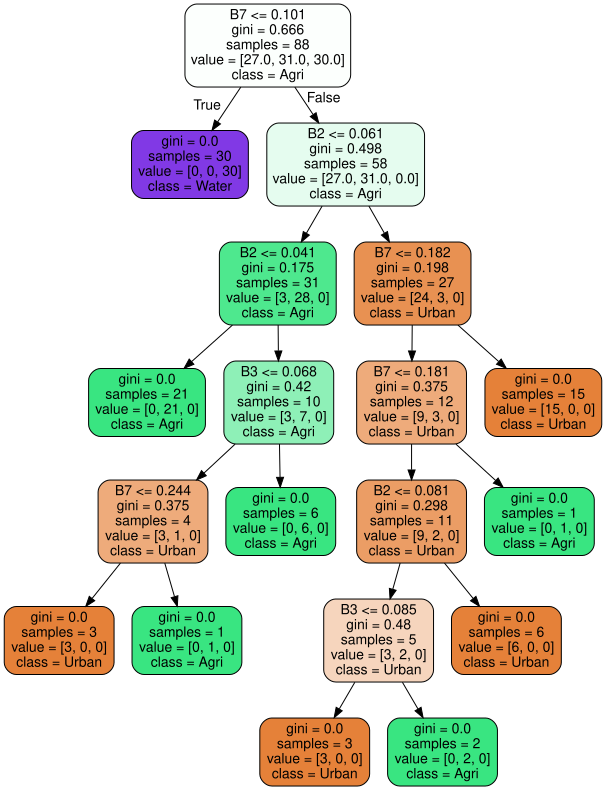

In [ ]:
import graphviz

# str(list(clf.classes_)[0]), str(list(clf.classes_)[1]), str(list(clf.classes_)[2])
dot_data = tree.export_graphviz(clf, feature_names=['B'+str(i+1) for i in listband] ,
                                class_names=['Urban','Agri','Water'],
                                filled=True,
                                rounded=True)
graph = graphviz.Source(dot_data)
graph

In [ ]:
clf.classes_

array([0, 1, 2])

In [ ]:
import pickle
pickle.dump(clf, open('mymodel.pkl','wb') )

In [ ]:
loaded_model = pickle.load(open('mymodel.pkl', 'rb'))

In [ ]:
loaded_model.predict(X_train)

array([1, 1, 0, 1, 1, 2, 2, 2, 0, 1, 2, 2, 1, 1, 0, 2, 2, 2, 1, 2, 1, 1,
       1, 0, 0, 2, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 1, 2, 2, 1,
       0, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 1, 0, 2, 0, 0, 1, 0, 0, 2,
       2, 0, 2, 2, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 0, 1, 1, 0, 1, 1])

In [ ]:
old_image = '/content/drive/MyDrive/GeoAI_SVCU/sentinel2_nonthaburi.tif'
new_image = '/content/myclassy.tif'

In [ ]:
import numpy as np
with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


In [ ]:
out = rio.open(new_image)

In [ ]:
classy_img = out.read()

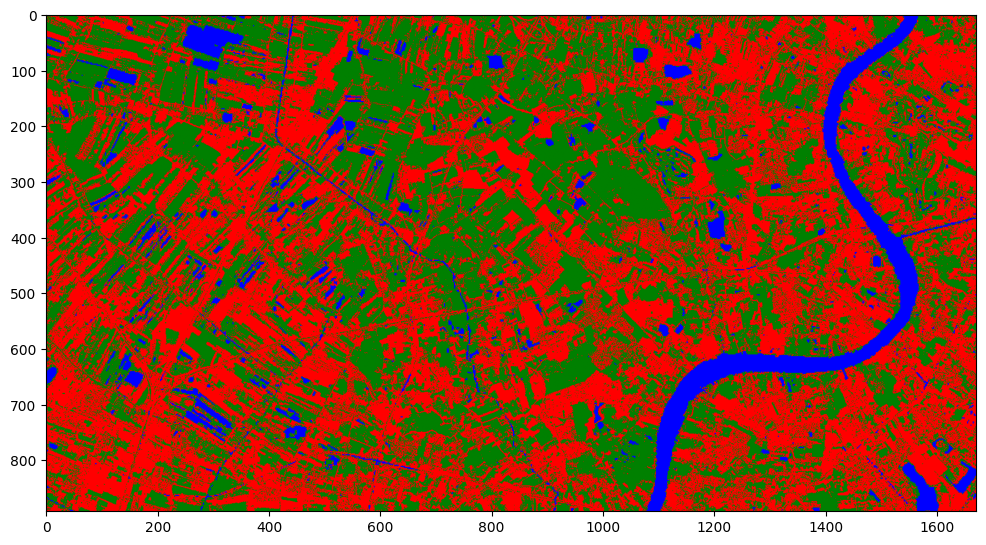

In [ ]:
from matplotlib import colors
fig,ax = plt.subplots(1,1, figsize=(12,24))

cmap = colors.ListedColormap(['red','green','blue'])
bounds=[-0.5,0.5,1.5]
norm = colors.BoundaryNorm(bounds, cmap.N)


plt.imshow(classy_img[0], cmap=cmap )

In [ ]:
X_test

,X,Y,1,2,3,6
19,100.489791,13.950880,0.0705,0.0805,0.1024,0.1812
45,100.407675,13.938047,0.1208,0.1270,0.1246,0.1395
141,100.508452,13.965617,0.0166,0.0189,0.0085,0.0047
30,100.456070,13.947138,0.0785,0.0890,0.0769,0.1979
67,100.422900,13.926412,0.0500,0.1068,0.0577,0.4643
...,...,...,...,...,...,...
128,100.539181,13.957937,0.0332,0.0490,0.0429,0.0128
25,100.440524,13.923461,0.0688,0.0918,0.1090,0.1828
23,100.453564,13.927637,0.0776,0.0891,0.0954,0.1046
139,100.498709,13.921564,0.0357,0.0508,0.0497,0.0144


In [ ]:
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
X_test

,X,Y,1,2,3,6,pred
19,100.489791,13.950880,0.0705,0.0805,0.1024,0.1812,1
45,100.407675,13.938047,0.1208,0.1270,0.1246,0.1395,0
141,100.508452,13.965617,0.0166,0.0189,0.0085,0.0047,2
30,100.456070,13.947138,0.0785,0.0890,0.0769,0.1979,0
67,100.422900,13.926412,0.0500,0.1068,0.0577,0.4643,1
...,...,...,...,...,...,...,...
128,100.539181,13.957937,0.0332,0.0490,0.0429,0.0128,2
25,100.440524,13.923461,0.0688,0.0918,0.1090,0.1828,0
23,100.453564,13.927637,0.0776,0.0891,0.0954,0.1046,1
139,100.498709,13.921564,0.0357,0.0508,0.0497,0.0144,2


In [ ]:
y_true = y_test.to_numpy()
y_true

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
y_pred = X_test['pred'].to_numpy()
y_pred

array([1, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 0, 1, 1, 1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 2, 0, 1, 1, 2,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 1, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 1, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2,
       1], dtype=uint8)

In [ ]:
confusion_matrix(y_true, y_pred)

array([[30,  3,  0],
       [ 3, 25,  1],
       [ 0,  2, 25]])

In [ ]:
print( classification_report(y_true, y_pred) )

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        33
           1       0.83      0.86      0.85        29
           2       0.96      0.93      0.94        27

    accuracy                           0.90        89
   macro avg       0.90      0.90      0.90        89
weighted avg       0.90      0.90      0.90        89



Try Random Forest Classification ....

Fitting 10 folds for each of 36 candidates, totalling 360 fits
Best Parameters:  {'max_features': None, 'min_samples_split': 3, 'n_estimators': 50}
Best CV Score:  0.8875
892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


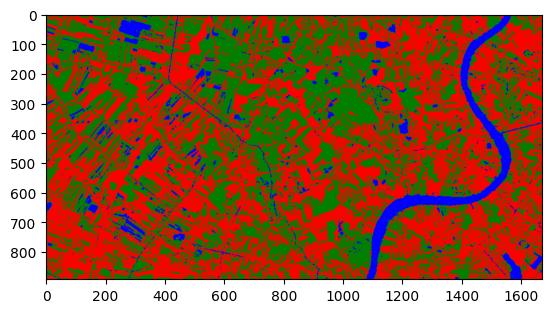

[[31  2  0]
 [ 3 25  1]
 [ 0  2 25]]
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.86      0.86      0.86        29
           2       0.96      0.93      0.94        27

    accuracy                           0.91        89
   macro avg       0.91      0.91      0.91        89
weighted avg       0.91      0.91      0.91        89



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define parameter grid for tuning
param_grid = {
    'min_samples_split': [2, 3, 4, 5],
    'max_features': ['sqrt', 'log2', None],
    'n_estimators': [20, 50, 100]
}

# Initialize model
rfmodel = RandomForestClassifier(random_state=42)

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=rfmodel,
    param_grid=param_grid,
    cv=10,               # 10-fold CV
    scoring='accuracy',  # or other metric
    n_jobs=-1,           # use all cores
    verbose=1
)

# Fit the model
grid_search.fit(X_train, y_train)

# Best parameters & best model
print("Best Parameters: ", grid_search.best_params_)
print("Best CV Score: ", grid_search.best_score_)

# Final best model
best_rf = grid_search.best_estimator_


mymod_RF = 'mymodel_RF.pkl'
pickle.dump(grid_search, open(mymod_RF,'wb') )

loaded_model = pickle.load(open(mymod_RF, 'rb'))
new_image = '/content/myclassy_RF.tif'

with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

# Open Image
out = rio.open(new_image)
classy_img_RF = out.read()

# Show Classified Class
plt.imshow(classy_img_RF[0], cmap=cmap )
plt.show()

# Sample Predicted Class
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
y_pred = X_test['pred'].to_numpy()

#Confusion Matrix Random Forest

print( confusion_matrix(y_true, y_pred) )

# Classification Report Random Forest
print( classification_report(y_true, y_pred) )


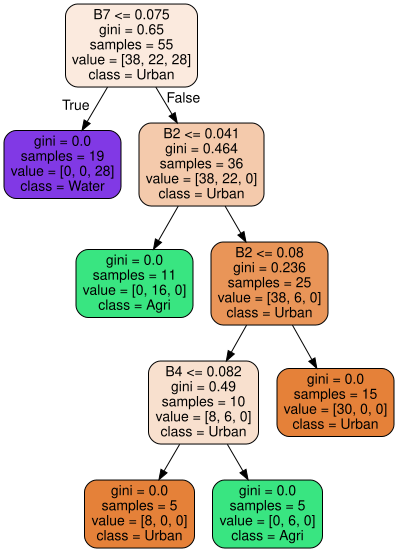

In [ ]:
#fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (2,2), dpi=800)

tree_id = 0 # <--- for i in range( len(n_estimator) )

best_rf = grid_search.best_estimator_
dot_data = tree.export_graphviz(best_rf.estimators_[tree_id], feature_names=['B'+str(i+1) for i in listband] ,
                                class_names=['Urban','Agri','Water'],
                                filled=True,
                                rounded=True)
#tree.plot_tree(rfc.estimators_[tree_id],feature_names=x.columns,class_names=['Builtup', 'Tree', 'Water'], filled=True,rounded=False,)
#fig.show()

graph = graphviz.Source(dot_data)
graph

Support Vector Machine Classification ...

Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Parameters: {'C': 100, 'degree': 4, 'gamma': 'scale', 'kernel': 'poly'}
Best CV Score: 0.9313725490196078
892 1671
(4, 892, 1671)
(892, 1671, 4)
(1490532, 4)
[0 0 0 ... 0 0 0]
(1490532,)


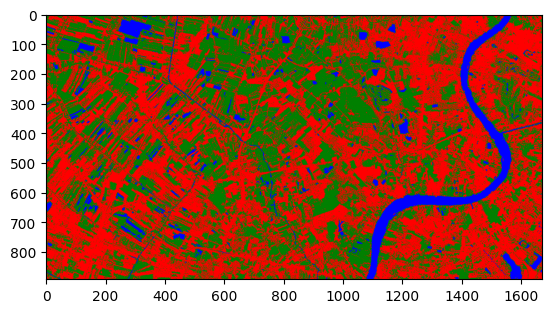

[[32  1  0]
 [ 3 26  0]
 [ 1  2 24]]
              precision    recall  f1-score   support

           0       0.89      0.97      0.93        33
           1       0.90      0.90      0.90        29
           2       1.00      0.89      0.94        27

    accuracy                           0.92        89
   macro avg       0.93      0.92      0.92        89
weighted avg       0.93      0.92      0.92        89



In [ ]:
from sklearn.svm import SVC

param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'degree': [2, 3, 4]  # used only for 'poly'
}

svm = SVC()

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)


SVM = grid_search.fit(X_train, y_train)

best_svm = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

mymod_SVM = 'mymodel_SVM.pkl'
pickle.dump(SVM, open(mymod_SVM,'wb') )

loaded_model = pickle.load(open(mymod_SVM, 'rb'))
new_image = '/content/myclassy_SVM.tif'

with rio.open(old_image,'r') as src:
  profile = src.profile
  profile.update( dtype=rio.uint8, count=1 )
  # row shape0, col shape1
  print(src.shape[0], src.shape[1])
  with rio.open(new_image, 'w', **profile) as dst:
    data = src.read([j+1 for j in listband])
    print( data.shape )
    img_swp = np.moveaxis(data, 0, 2 )
    print( img_swp.shape )
    img_flat = img_swp.reshape(-1, img_swp.shape[-1])
    print( img_flat.shape )
    img_flat = np.nan_to_num(img_flat)
    img_preds = loaded_model.predict(img_flat)
    print( img_preds )
    print( img_preds.shape )

    output = img_preds.reshape(*img_swp.shape[:-1])
    dst.write( output.astype(rio.uint8) , 1)

# Open Image
out = rio.open(new_image)
classy_img_SVM = out.read()

# Show Classified Class
plt.imshow(classy_img_SVM[0], cmap=cmap )
plt.show()

# Sample Predicted Class
X_test['pred'] = [ x[0] for x in out.sample( [(x,y) for x,y in zip(X_test.X, X_test.Y)] ) ]
y_pred = X_test['pred'].to_numpy()

#Confusion Matrix Random Forest

print( confusion_matrix(y_true, y_pred) )

# Classification Report Random Forest
print( classification_report(y_true, y_pred) )

Final Boss .... Neural Network !!!

In [ ]:
num_classes = len(np.array(np.unique( y_test )))
num_classes

3

In [ ]:
from keras.utils import plot_model

# modeling
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from keras.optimizers import RMSprop
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


In [ ]:
yy_train = keras.utils.to_categorical(y_train, num_classes)
yy_test = keras.utils.to_categorical(y_test, num_classes)

In [ ]:
y_train, yy_train

(79     1
 84     1
 39     0
 101    1
 86     1
       ..
 71     1
 106    1
 14     0
 92     1
 102    1
 Name: class, Length: 88, dtype: int64,
 array([[0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [0., 0., 1.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 1., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.],
        [0., 1

In [ ]:
# save model to here
model_file = '/content/M1.keras'

checkpoint = keras.callbacks.ModelCheckpoint(filepath = model_file,
                                             monitor = 'val_loss',
                                             save_best_only = True)

callback_list = [checkpoint]

In [ ]:
M1 = Sequential()

M1.add(Dense(256, activation='relu', input_shape=(4,)))
M1.add(Dropout(0.2))
M1.add(Dense(num_classes, activation='softmax'))
M1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,051 (8.01 KB)

 Trainable params: 2,051 (8.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
M1.compile(loss='categorical_crossentropy',
              optimizer=RMSprop(),
              metrics=['accuracy'])

In [ ]:
batch_size = 5
epochs = 100

In [ ]:
history = M1.fit(X_train.to_numpy(), yy_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    callbacks = callback_list,
                    validation_data=(X_test[listband], yy_test))

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.5114 - loss: 1.0712 - val_accuracy: 0.6854 - val_loss: 1.0461
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 1.0376 - val_accuracy: 0.8090 - val_loss: 1.0179
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8295 - loss: 1.0078 - val_accuracy: 0.8427 - val_loss: 0.9920
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8523 - loss: 0.9817 - val_accuracy: 0.8652 - val_loss: 0.9656
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8409 - loss: 0.9544 - val_accuracy: 0.8764 - val_loss: 0.9369
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8523 - loss: 0.9241 - val_accuracy: 0.8989 - val_loss: 0.9074
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8409 - loss: 0.8923 - val_accuracy: 0.9101 - val_loss: 0.8763
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8750 - loss: 0.8591 - val_accuracy: 0.8764 -

In [ ]:
score = M1.evaluate(X_test[listband], yy_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.26408651471138
Test accuracy: 0.898876428604126


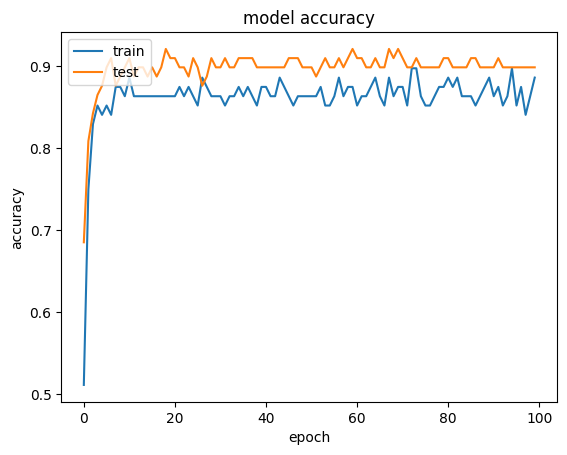

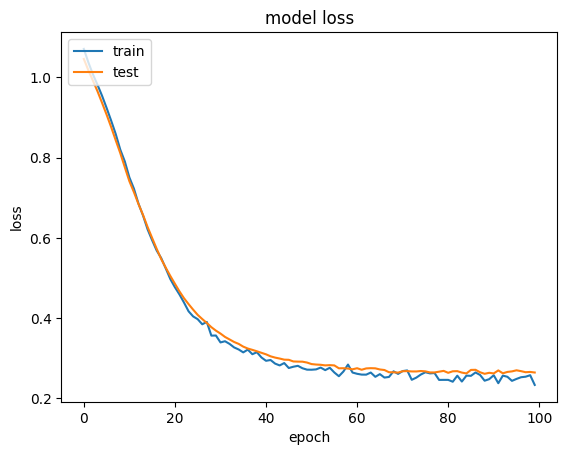

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

ขอขี้โกงนะจ๊ะ ไม่รันภาพให้ดูแล้ววววว

In [ ]:
y_test_true_tmp = np.argmax(yy_test, axis = 1)
y_test_true_tmp

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
y_test_pred_tmp = M1.predict(X_test[listband])
y_test_pred_tmp[:10]

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


array([[6.5993023e-01, 3.3723348e-01, 2.8363166e-03],
       [9.4643962e-01, 5.2264318e-02, 1.2960578e-03],
       [1.2548115e-03, 5.5945911e-03, 9.9315047e-01],
       [5.8775210e-01, 4.1050890e-01, 1.7390561e-03],
       [1.1200419e-01, 8.8799578e-01, 1.0953889e-08],
       [9.6174902e-01, 3.8047589e-02, 2.0343222e-04],
       [2.9975450e-01, 6.9174236e-01, 8.5031567e-03],
       [2.3956562e-03, 1.0500533e-02, 9.8710388e-01],
       [7.1903951e-02, 9.2806298e-01, 3.2920845e-05],
       [1.7003485e-03, 7.5845728e-03, 9.9071503e-01]], dtype=float32)

In [ ]:
y_pred = np.argmax(y_test_pred_tmp , axis = 1)
y_pred

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 0, 1, 1, 2,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 0, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 1, 0, 0, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
y_true = y_test_true_tmp
y_true

array([0, 0, 2, 0, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 2, 2, 1, 2, 0, 1, 1, 1,
       2, 0, 1, 2, 2, 0, 1, 0, 0, 2, 2, 1, 1, 0, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 2, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 1, 0, 1, 0, 0, 2, 0, 0, 2,
       1])

In [ ]:
#Confusion Matrix

print( confusion_matrix(y_true, y_pred) )

# Classification Report
print( classification_report(y_true, y_pred) )

[[32  1  0]
 [ 4 24  1]
 [ 3  0 24]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89        33
           1       0.96      0.83      0.89        29
           2       0.96      0.89      0.92        27

    accuracy                           0.90        89
   macro avg       0.91      0.90      0.90        89
weighted avg       0.91      0.90      0.90        89



Thepchai Srinoi, Department of Survey Engineering Chulalongkorn University 2026